In [1]:
import pandas as pd

df_prc = pd.read_pickle("C:/Users/hp/Downloads/TER_M1_2025/data/ENQUETE_PRC_BC")
print(" Données PRC ")
print("Nombre de lignes :", len(df_prc))
print("Colonnes :", df_prc.columns.tolist())
print(df_prc.head(), "\n")
## ca prend presque 10 mins pour le loading de l'excel vu sa grande taille désolé :/
df_soins = pd.read_excel("C:/Users/hp/Downloads/TER_M1_2025/data/df_all_care_T0_no_filtered.xlsx")
print(" Données de Soins ")
print("Nombre de lignes :", len(df_soins))
print("Colonnes :", df_soins.columns.tolist())
print(df_soins.head())


 Données PRC 
Nombre de lignes : 930
Colonnes : ['ID_PATIENT', 'peur_recidive1']
   ID_PATIENT  peur_recidive1
0  1101100325               2
1  1101100717               3
2  1101100766               1
3  1102100494               2
4  1102101103               3 

 Données de Soins 
Nombre de lignes : 485287
Colonnes : ['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen', 'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire', 'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner', 'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns', 'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan', 'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore', 'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen', 'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part', 'SURG', 'T0', 'TREATMENT_TYPE']
   ID_PATIENT     CODE  DAYS_SINCE_DIAG TABLE_ORIGIN  Cons_Med_Gen  Cons_Spe  \
0  3104503184  D01AC12                0   

In [2]:
df_soins.to_csv("df_soins.csv", index=False)


In [3]:
df_soins = pd.read_csv("df_soins.csv")
df_soins.columns


Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE'],
      dtype='object')

In [4]:
def recoder_prc(classe):
    if classe in [1, 2]:
        return 0  
    elif classe == 3:
        return 1  
    else:
        return None  

df_prc['PRC'] = df_prc['peur_recidive1'].apply(recoder_prc)

In [8]:
df_prc.head(20)

,ID_PATIENT,PRC
0,1101100325,0
1,1101100717,1
2,1101100766,0
3,1102100494,0
4,1102101103,1
5,1102101659,0
6,1102102186,1
7,1103100275,0
8,1103101510,0
9,1103102437,0


In [9]:
df_prc = df_prc[['ID_PATIENT', 'PRC']]


In [10]:
df_prc.head(5 )

,ID_PATIENT,PRC
0,1101100325,0
1,1101100717,1
2,1101100766,0
3,1102100494,0
4,1102101103,1


In [11]:
df_merged = df_soins.merge(df_prc, on='ID_PATIENT', how='inner')

In [12]:
df_merged.head(900)

,ID_PATIENT,CODE,DAYS_SINCE_DIAG,TABLE_ORIGIN,Cons_Med_Gen,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Echo_Abdominal,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
0,3104503184,D01AC12,0,medic,0,1,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
1,3104503184,G01AF12,0,medic,0,1,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
2,3104503184,N07BA01,4,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
3,3104503184,C509,13,pmsi,0,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
4,3104503184,FCFA021,13,psmi_act,0,0,0,0,0,0,...,0,0,0,0,0,0,1,161,"CT, HT, RT, SURG",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,4105904747,9105,1351,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
896,4105904747,QEQM001,1353,ccam,0,0,0,1,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
897,4105904747,QEQK001,1353,ccam,0,0,1,0,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
898,4105904747,L02BG03,1360,medic,0,1,0,0,0,0,...,0,1,0,0,0,0,0,102,"SURG, RT, HT",0


In [13]:
print("Nombre de patientes uniques :", df_merged['ID_PATIENT'].nunique())


Nombre de patientes uniques : 920


In [14]:
df_post_T0 = df_merged[df_merged["DAYS_SINCE_DIAG"] >= df_merged["T0"]]

In [15]:
df_post_T0

,ID_PATIENT,CODE,DAYS_SINCE_DIAG,TABLE_ORIGIN,Cons_Med_Gen,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Echo_Abdominal,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
235,3104503184,9005,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
236,3104503184,9105,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
237,3104503184,7321,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
238,3104503184,2258,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
239,3104503184,0514,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485282,4308300843,L02BG03,888,medic,0,1,0,0,0,0,...,0,1,0,0,0,0,0,804,HT,0
485283,3107502798,L02BG03,1060,medic,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1060,HT,1
485284,3107502798,V08AB10,1106,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1060,HT,1
485285,3107502798,V08BA02,1106,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1060,HT,1


In [16]:
df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


C:\Users\hp\AppData\Local\Temp\ipykernel_31116\1400350702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


In [ ]:
actes_suivi = [
    "Cons_Spe",
    "Mammographie", "Echo_Mammaire", "Irm_Mammaire",
    "Fns", "Ca_15_3",
    "Bilan_Hepatique", "Bilan_Lipidique",
    "Echo_pelv", "Echo_endometre",       
    "Osteodensitometrie",               
    "Dosage_pholphocalcique"            
]

In [22]:
df_suivi_filtré = df_post_T0[df_post_T0[actes_suivi].sum(axis=1) >= 1]


In [23]:
print("Nombre d’actes post-T0 pertinents au suivi :", len(df_suivi_filtré))
print(df_suivi_filtré[["ID_PATIENT", "mois_depuis_T0", "PRC"] + actes_suivi].head())


Nombre d’actes post-T0 pertinents au suivi : 76828
     ID_PATIENT  mois_depuis_T0  PRC  Cons_Spe  Mammographie  Echo_Mammaire  \
237  3104503184               0    1         0             0              0   
239  3104503184               0    1         0             0              0   
240  3104503184               0    1         0             0              0   
241  3104503184               0    1         0             0              0   
243  3104503184               0    1         0             0              0   

     Irm_Mammaire  Fns  Ca_15_3  Bilan_Hepatique  Bilan_Lipidique  Echo_pelv  \
237             0    0        1                0                0          0   
239             0    0        0                1                0          0   
240             0    0        0                1                0          0   
241             0    0        0                1                0          0   
243             0    0        0                0                0         

In [27]:
## de facon régulière 
def assigner_periode(mois):
    if mois < 0:
        return None
    elif mois < 3:
        return "M0–M3"
    elif mois < 6:
        return "M3–M6"
    elif mois < 9:
        return "M6–M9"
    elif mois < 12:
        return "M9–M12"
    elif mois < 15:
        return "M12–M15"
    elif mois < 18:
        return "M15–M18"
    elif mois < 21:
        return "M18–M21"
    elif mois < 24:
        return "M21–M24"
    elif mois < 27:
        return "M24–M27"
    elif mois < 30:
        return "M27–M30"
    elif mois < 33:
        return "M30–M33"
    elif mois < 36:
        return "M33–M36"
    elif mois < 39:
        return "M36–M39"
    elif mois < 42:
        return "M39–M42"
    elif mois < 45:
        return "M42–M45"
    elif mois < 48:
        return "M45–M48"
    elif mois < 51:
        return "M48–M51"
    elif mois < 54:
        return "M51–M54"
    elif mois < 57:
        return "M54–M57"
    elif mois < 60:
        return "M57–M60"
    else:
        return "M60+"

df_suivi_filtré["periode_suivi"] = df_suivi_filtré["mois_depuis_T0"].apply(assigner_periode)
df_resumé_par_periode = df_suivi_filtré.groupby(["ID_PATIENT", "periode_suivi", "PRC"])[actes_suivi].sum().reset_index()
print(df_resumé_par_periode.head(10))


   ID_PATIENT periode_suivi  PRC  Cons_Spe  Mammographie  Echo_Mammaire  \
0  1101100325         M0–M3    0         7             1              1   
1  1101100325       M12–M15    0         0             0              0   
2  1101100325       M15–M18    0         0             1              0   
3  1101100325       M18–M21    0         0             0              0   
4  1101100325       M27–M30    0         1             1              1   
5  1101100325       M33–M36    0         0             0              0   
6  1101100325       M36–M39    0         0             0              0   
7  1101100325       M39–M42    0         0             1              1   
8  1101100325         M3–M6    0         0             0              0   
9  1101100325       M42–M45    0         0             0              0   

   Irm_Mammaire  Fns  Ca_15_3  Bilan_Hepatique  Bilan_Lipidique  Echo_pelv  \
0             0    0        0                4                0          0   
1             0   

C:\Users\hp\AppData\Local\Temp\ipykernel_31116\2103788939.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_suivi_filtré["periode_suivi"] = df_suivi_filtré["mois_depuis_T0"].apply(assigner_periode)


In [28]:
moyennes_par_prc = df_resumé_par_periode.groupby("PRC")[actes_suivi].mean().T
moyennes_par_prc.columns = ["PRC_0", "PRC_1"]
print(moyennes_par_prc)

                           PRC_0     PRC_1
Cons_Spe                3.244835  3.607068
Mammographie            0.352558  0.320993
Echo_Mammaire           0.309729  0.293647
Irm_Mammaire            0.022668  0.028607
Fns                     0.629087  0.656289
Ca_15_3                 0.304814  0.323517
Bilan_Hepatique         1.354463  1.361801
Bilan_Lipidique         0.351856  0.336138
Echo_pelv               0.073220  0.073202
Echo_endometre          0.229188  0.233908
Osteodensitometrie      0.049649  0.045856
Dosage_pholphocalcique  0.287462  0.290282


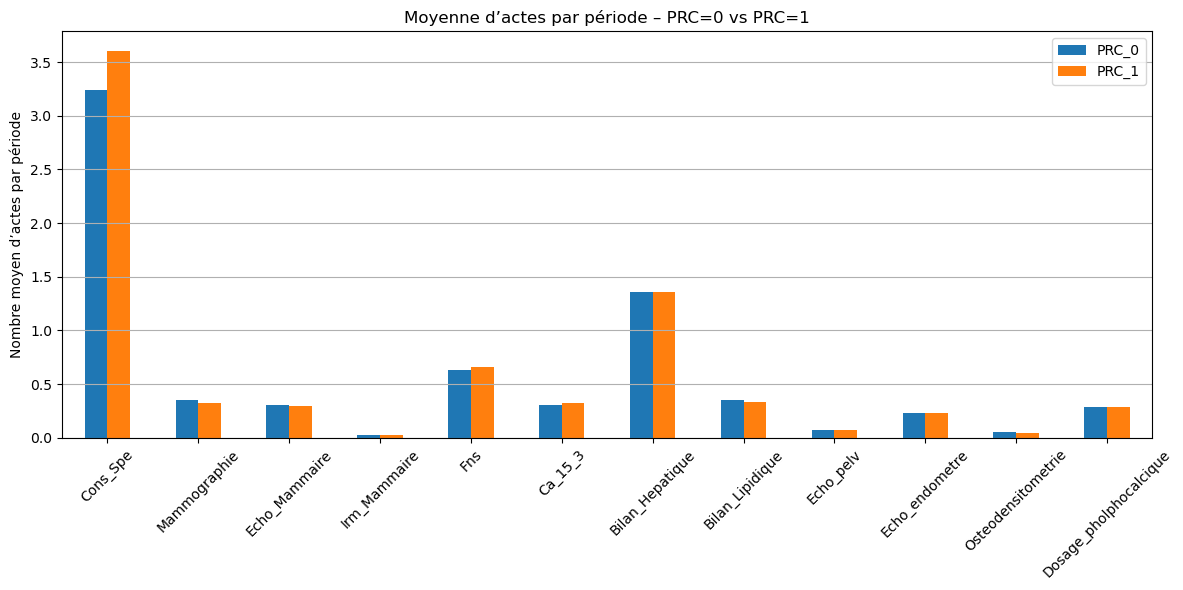

In [29]:
import matplotlib.pyplot as plt

moyennes_par_prc.plot(kind='bar', figsize=(12, 6))
plt.title("Moyenne d’actes par période – PRC=0 vs PRC=1")
plt.ylabel("Nombre moyen d’actes par période")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

 Les patientes du groupe PRC = 1 présentent un suivi  plus intensif, notamment en ce qui concerne les consultations de médecine générale (en moyenne 52 contre 47 actes par période) et les consultations spécialisées. Elles effectuent également plus fréquemment certains bilans biologiques tels que le bilan hépatique ou le dosage du CA 15-3. En revanche, les examens d’imagerie comme la mammographie ou l’IRM mammaire restent globalement équivalents entre les deux groupes

In [20]:
df_post_T0.to_csv("C:/Users/hp/Downloads/df_post_T0.csv", index=False)
df_suivi_filtré.to_csv("C:/Users/hp/Downloads/df_suivi_filtré.csv", index=False)


In [21]:
df_post_T0.columns

Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE', 'PRC', 'mois_depuis_T0'],
      dtype='object')

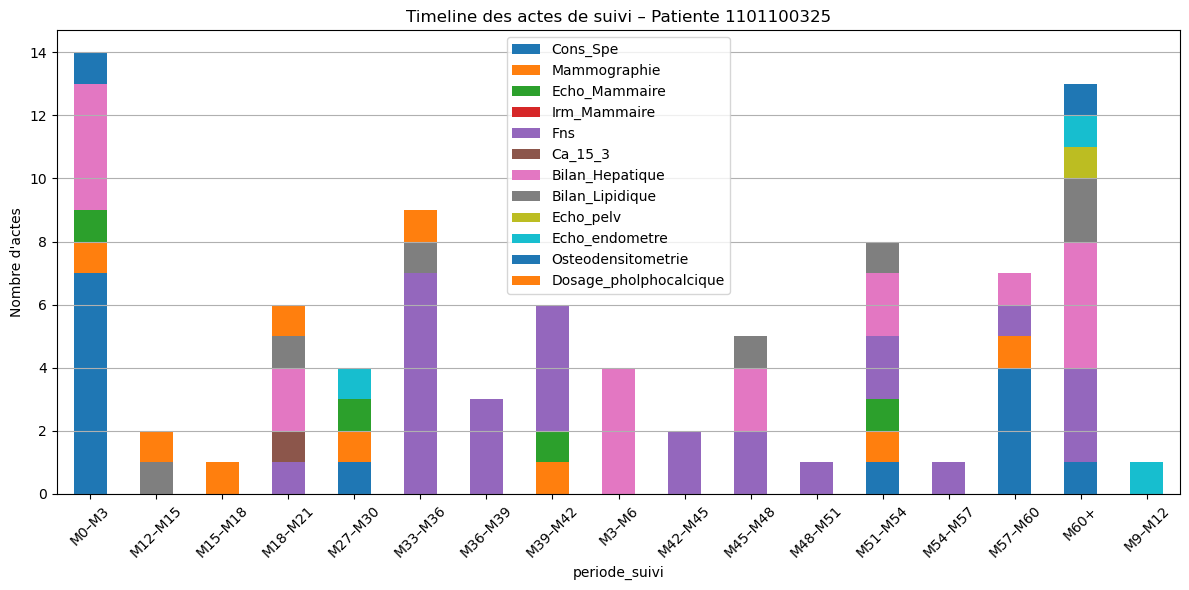

In [30]:

id_exemple = df_resumé_par_periode["ID_PATIENT"].iloc[0]
df_patient = df_resumé_par_periode[df_resumé_par_periode["ID_PATIENT"] == id_exemple]

df_patient.set_index("periode_suivi")[actes_suivi].plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"Timeline des actes de suivi – Patiente {id_exemple}")
plt.ylabel("Nombre d'actes")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [31]:
df_vecteurs = df_resumé_par_periode.copy()
df_vecteurs[actes_suivi] = (df_vecteurs[actes_suivi] > 0).astype(int)


In [32]:
###nécessaire pour faire de l'analyse ou appliquer des modeles ! 
df_vecteurs

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,Bilan_Lipidique,Echo_pelv,Echo_endometre,Osteodensitometrie,Dosage_pholphocalcique
0,1101100325,M0–M3,0,1,1,1,0,0,0,1,0,0,0,1,0
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,1,0,0,0,1
2,1101100325,M15–M18,0,0,1,0,0,0,0,0,0,0,0,0,0
3,1101100325,M18–M21,0,0,0,0,0,1,1,1,1,0,0,0,1
4,1101100325,M27–M30,0,1,1,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12342,4309400482,M30–M33,0,0,1,1,0,1,1,1,0,0,0,0,1
12343,4309400482,M39–M42,0,0,0,0,0,0,0,0,0,0,0,1,0
12344,4309400482,M42–M45,0,0,1,1,0,1,1,1,1,0,0,0,1
12345,4309400482,M57–M60,0,0,1,1,0,0,0,0,0,0,0,0,0


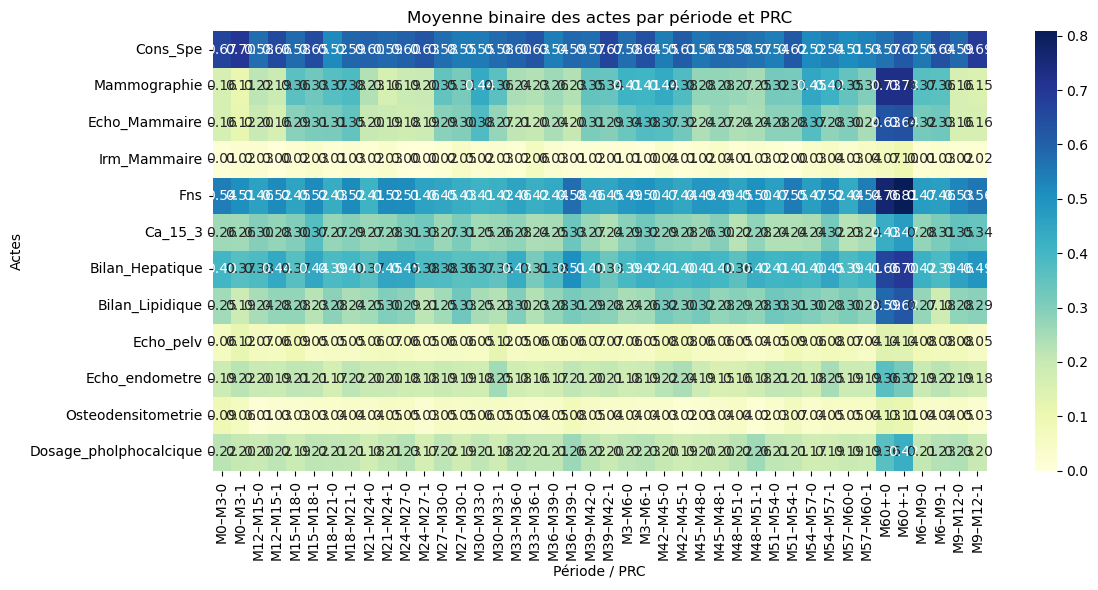

In [34]:
import seaborn as sns

df_heatmap = df_vecteurs.groupby(["periode_suivi", "PRC"])[actes_suivi].mean().T

plt.figure(figsize=(12, 6))
sns.heatmap(df_heatmap, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Moyenne binaire des actes par période et PRC")
plt.ylabel("Actes")
plt.xlabel("Période / PRC")
plt.tight_layout()
plt.show()


Les premières analyses descriptives (moyennes, heatmaps) montrent que les femmes avec PRC=1 présentent un suivi plus fréquent que celles avec PRC=0, en particulier au niveau des consultations médicales et bilans biologiques, dès les premiers mois post-traitement.

<AxesSubplot:>

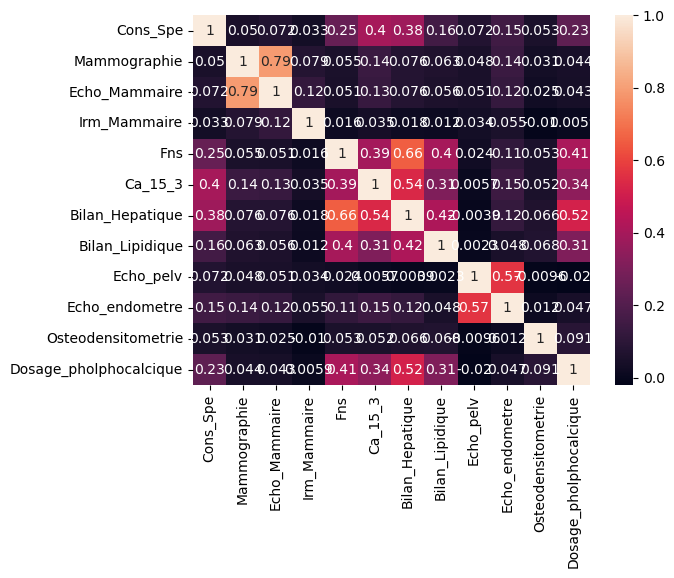

In [35]:
corr = df_resumé_par_periode[actes_suivi].corr()
sns.heatmap(corr, annot=True)


In [36]:
df_var = df_resumé_par_periode.groupby("ID_PATIENT")[actes_suivi].std()


In [44]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,Bilan_Lipidique,Echo_pelv,Echo_endometre,Osteodensitometrie,Dosage_pholphocalcique
0,1101100325,M0–M3,0,7,1,1,0,0,0,4,0,0,0,1,0
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,1,0,0,0,1
2,1101100325,M15–M18,0,0,1,0,0,0,0,0,0,0,0,0,0
3,1101100325,M18–M21,0,0,0,0,0,1,1,2,1,0,0,0,1
4,1101100325,M27–M30,0,1,1,1,0,0,0,0,0,0,1,0,0
5,1101100325,M33–M36,0,0,0,0,0,7,0,0,1,0,0,0,1
6,1101100325,M36–M39,0,0,0,0,0,3,0,0,0,0,0,0,0
7,1101100325,M39–M42,0,0,1,1,0,4,0,0,0,0,0,0,0
8,1101100325,M3–M6,0,0,0,0,0,0,0,4,0,0,0,0,0
9,1101100325,M42–M45,0,0,0,0,0,2,0,0,0,0,0,0,0


## Etude de Conformité avec les recommendations du PSP

In [46]:
for acte in actes_suivi:
    if acte in df_resumé_par_periode.columns:
        df_resumé_par_periode[f"conf_{acte}"] = (df_resumé_par_periode[acte] >= 1).astype(int)

In [48]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,...,conf_Echo_Mammaire,conf_Irm_Mammaire,conf_Fns,conf_Ca_15_3,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
0,1101100325,M0–M3,0,7,1,1,0,0,0,4,...,1,0,0,0,1,0,0,0,1,0
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,1101100325,M15–M18,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1101100325,M18–M21,0,0,0,0,0,1,1,2,...,0,0,1,1,1,1,0,0,0,1
4,1101100325,M27–M30,0,1,1,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
5,1101100325,M33–M36,0,0,0,0,0,7,0,0,...,0,0,1,0,0,1,0,0,0,1
6,1101100325,M36–M39,0,0,0,0,0,3,0,0,...,0,0,1,0,0,0,0,0,0,0
7,1101100325,M39–M42,0,0,1,1,0,4,0,0,...,1,0,1,0,0,0,0,0,0,0
8,1101100325,M3–M6,0,0,0,0,0,0,0,4,...,0,0,0,0,1,0,0,0,0,0
9,1101100325,M42–M45,0,0,0,0,0,2,0,0,...,0,0,1,0,0,0,0,0,0,0


In [50]:
traitements = df_merged.groupby("ID_PATIENT")[["Tamoxifen", "Anti_arom", "CT"]].max().reset_index()
df_resumé_par_periode = df_resumé_par_periode.merge(traitements, on="ID_PATIENT", how="left")

# Conformité spécifique : gynécologie si tamoxifène
df_resumé_par_periode["conf_Echo_pelv"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["Tamoxifen"] == 1 and row.get("Echo_pelv", 0) >= 1 else 0, axis=1
)
df_resumé_par_periode["conf_Echo_endometre"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["Tamoxifen"] == 1 and row.get("Echo_endometre", 0) >= 1 else 0, axis=1
)

# Si anti-aromatase : ostéodensitométrie et bilan phosphocalcique
df_resumé_par_periode["conf_Osteodensitometrie"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["Anti_arom"] == 1 and row.get("Osteodensitometrie", 0) >= 1 else 0, axis=1
)
df_resumé_par_periode["conf_Dosage_pholphocalcique"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["Anti_arom"] == 1 and row.get("Dosage_pholphocalcique", 0) >= 1 else 0, axis=1
)

# Évaluation cardiaque si chimio
df_resumé_par_periode["conf_Evaluation_Cardiaque"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["CT"] == 1 and row.get("Evaluation_Cardiaque", 0) >= 1 else 0, axis=1
)

In [51]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,...,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique,Tamoxifen,Anti_arom,CT,conf_Evaluation_Cardiaque
0,1101100325,M0–M3,0,7,1,1,0,0,0,4,...,1,0,0,0,1,0,0,1,1,0
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,1,1,0
2,1101100325,M15–M18,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
3,1101100325,M18–M21,0,0,0,0,0,1,1,2,...,1,1,0,0,0,1,0,1,1,0
4,1101100325,M27–M30,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
5,1101100325,M33–M36,0,0,0,0,0,7,0,0,...,0,1,0,0,0,1,0,1,1,0
6,1101100325,M36–M39,0,0,0,0,0,3,0,0,...,0,0,0,0,0,0,0,1,1,0
7,1101100325,M39–M42,0,0,1,1,0,4,0,0,...,0,0,0,0,0,0,0,1,1,0
8,1101100325,M3–M6,0,0,0,0,0,0,0,4,...,1,0,0,0,0,0,0,1,1,0
9,1101100325,M42–M45,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,1,1,0


Score de conformité : 1     3563
2     2214
3     2110
4     1504
5     1202
6      812
7      503
8      236
0      122
9       60
10      19
11       2
Name: score_conformité, dtype: int64


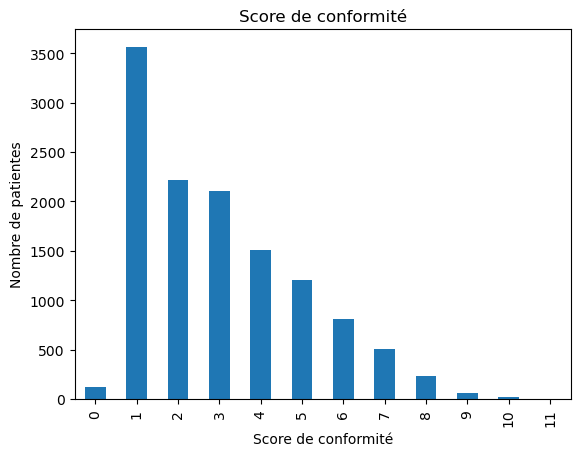

In [52]:
colonnes_conf = [col for col in df_resumé_par_periode.columns if col.startswith("conf_")]
df_resumé_par_periode["score_conformité"] = df_resumé_par_periode[colonnes_conf].sum(axis=1)
print("Score de conformité :", df_resumé_par_periode["score_conformité"].value_counts())
df_resumé_par_periode["score_conformité"].value_counts().sort_index().plot(kind="bar")
import matplotlib.pyplot as plt
plt.title("Score de conformité")
plt.xlabel("Score de conformité")
plt.ylabel("Nombre de patientes")
plt.show()
df_resumé_par_periode.to_csv("df_resumé_par_periode.csv", index=False)
df_resumé_par_periode = pd.read_csv("df_resumé_par_periode.csv")


Le score modal (= le plus fréquent) est 1, ce qui suggère que dans la plupart des cas, seul un acte recommandé est réalisé.

Un score élevé (7 à 13) est rare, représentant moins de 10% des observations.

Cela indique une adhérence partielle au plan de suivi, avec une majorité de patientes effectuant peu d’actes recommandés par période de 3 mois.

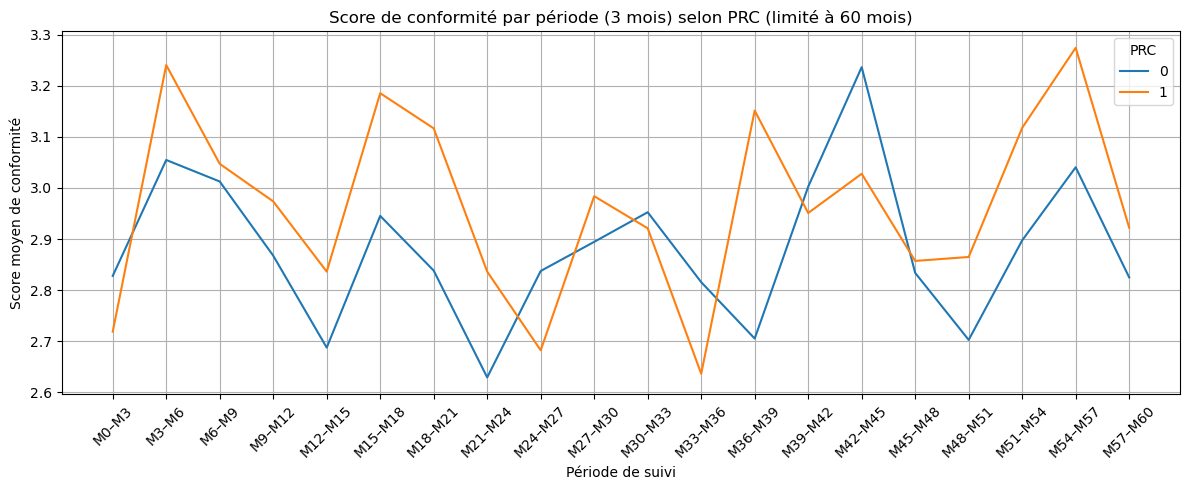

In [53]:
df_plot = df_resumé_par_periode[df_resumé_par_periode["periode_suivi"] != "M60+"].copy()

ordre = sorted(df_plot["periode_suivi"].dropna().unique(), key=lambda x: int(x[1:].split("–")[0]))

df_plot["periode_suivi"] = pd.Categorical(df_plot["periode_suivi"], categories=ordre, ordered=True)

df_plot = df_plot.sort_values("periode_suivi")

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_plot, x="periode_suivi", y="score_conformité", hue="PRC", estimator="mean", ci=None)
plt.title("Score de conformité par période (3 mois) selon PRC (limité à 60 mois)")
plt.xlabel("Période de suivi")
plt.ylabel("Score moyen de conformité")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

La conformité diminue dans le temps, mais les patientes PRC=1 restent légèrement plus engagées dans leur suivi.
Cela illustre un effet léger mais constant de la peur de récidive sur l'adhésion au suivi médical recommandé.

## Traitement d'Excès d'actes médicaux 

In [36]:
from scipy.stats import shapiro, ttest_ind
 
df_suivi_filtré = df_suivi_filtré[df_suivi_filtré["Cons_Spe"].isin([0, 1])]
df_suivi_filtré = df_suivi_filtré.dropna(subset=["PRC", "Cons_Spe"])

# 2. Séparation des groupes
groupe_0 = df_suivi_filtré[df_suivi_filtré["PRC"] == 0]["Cons_Spe"]
groupe_1 = df_suivi_filtré[df_suivi_filtré["PRC"] == 1]["Cons_Spe"]


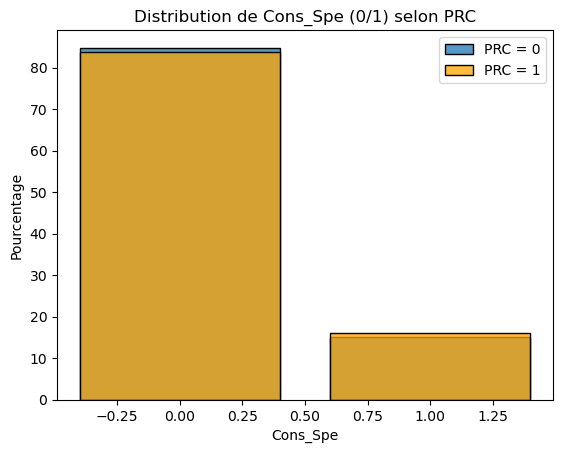

In [37]:
sns.histplot(groupe_0, stat="percent", discrete=True, shrink=0.8, label="PRC = 0")
sns.histplot(groupe_1, stat="percent", discrete=True, shrink=0.8, label="PRC = 1", color="orange")
plt.title("Distribution de Cons_Spe (0/1) selon PRC")
plt.xlabel("Cons_Spe")
plt.ylabel("Pourcentage")
plt.legend()
plt.show()

In [38]:
t_stat, p_value = ttest_ind(groupe_0, groupe_1, equal_var=False)

print("\nT-test")
print("t =", round(t_stat, 3))
print("p-value =", round(p_value, 6))


T-test
t = -5.26
p-value = 0.0


Evaluer si la variable PRC (peur de récidive) a un effet sur la probabilité qu’une patiente ait eu une consultation spécialisée (Cons_Spe).

Le rôle du t-test :

Il permet de comparer les moyennes de Cons_Spe dans deux groupes indépendants : PRC = 0 (peur faible) et PRC = 1 (peur élevée). 

Il prend en compte la différence entre les moyennes, la variabilité interne de chaque groupe, et la taille des échantillons.

Résultats du test
Statistique t : t = -5.26

Cela indique que la différence entre les moyennes est importante et négative, donc la moyenne du groupe PRC = 1 est supérieure à celle du groupe PRC = 0.

p-value : p < 0.001

Cela signifie que la probabilité que cette différence soit due au hasard est inférieure à 0.1%.

La différence est donc hautement significativ grace a a la p-value !!!! 



Il y a une différence réelle entre les deux groupes : la peur de récidive influence le comportement médical.

Les patientes ayant une peur élevée de récidive (PRC = 1) consultent significativement plus souvent un spécialiste (Cons_Spe = 1) que celles ayant une peur faible (PRC = 0).